# Animated Cat Chasing a Mouse

This notebook creates a simple animation where a cat (red circle) chases a mouse (blue circle). The mouse runs along a sinusoidal path while the cat follows using a basic pursuit curve.

In [1]:
%matplotlib inline
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.animation import FuncAnimation
from IPython.display import HTML

In [2]:
# Parameters
n_frames = 200
t_max = 4 * np.pi
t = np.linspace(0, t_max, n_frames)

# Mouse trajectory: sinusoidal
mouse_x = t
mouse_y = 0.5 * np.sin(2 * t)

# Cat starts at origin, chases with constant speed
cat_speed = 0.03
cat_x = np.zeros(n_frames)
cat_y = np.zeros(n_frames)
cat_x[0], cat_y[0] = 0.0, -0.5

for i in range(1, n_frames):
    dx = mouse_x[i-1] - cat_x[i-1]
    dy = mouse_y[i-1] - cat_y[i-1]
    dist = np.hypot(dx, dy)
    if dist > 1e-6:
        cat_x[i] = cat_x[i-1] + cat_speed * dx / dist
        cat_y[i] = cat_y[i-1] + cat_speed * dy / dist
    else:
        cat_x[i], cat_y[i] = cat_x[i-1], cat_y[i-1]


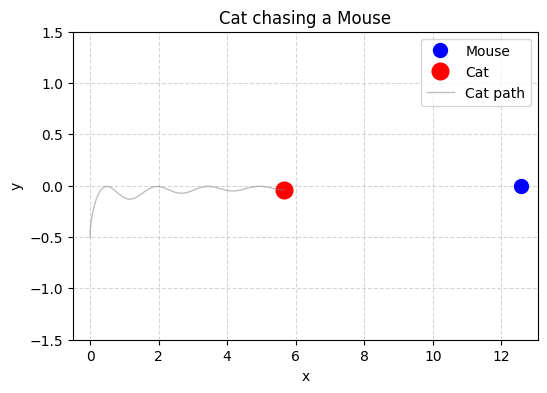

In [3]:
# Set up figure
fig, ax = plt.subplots(figsize=(6,4))
ax.set_xlim(t.min()-0.5, t.max()+0.5)
ax.set_ylim(-1.5, 1.5)
ax.set_xlabel('x')
ax.set_ylabel('y')
ax.set_title('Cat chasing a Mouse')
ax.grid(True, linestyle='--', alpha=0.5)

# Artists
mouse_dot, = ax.plot([], [], 'o', color='blue', markersize=10, label='Mouse')
cat_dot, = ax.plot([], [], 'o', color='red', markersize=12, label='Cat')
trail, = ax.plot([], [], '-', color='gray', lw=1, alpha=0.5, label='Cat path')
ax.legend(loc='upper right')

def init():
    mouse_dot.set_data([], [])
    cat_dot.set_data([], [])
    trail.set_data([], [])
    return mouse_dot, cat_dot, trail

def animate(i):
    # mouse
    mouse_dot.set_data([mouse_x[i]], [mouse_y[i]])
    # cat
    cat_dot.set_data([cat_x[i]], [cat_y[i]])
    # trail of cat up to current frame
    trail.set_data(cat_x[:i+1], cat_y[:i+1])
    return mouse_dot, cat_dot, trail

anim = FuncAnimation(fig, animate, frames=n_frames,
                     init_func=init, interval=50, blit=True)

# To display in notebook
HTML(anim.to_jshtml())